# 1. Getting Data

Here, we use only the front-month continuous contract, ES.c.0. Since ES.c.0 is a continuous contract rather than an individual futures contract, it does not have a fixed expiration date. Instead, it dynamically maps to a specific underlying futures contract at each point in time and rolls from the current front-month contract to the next contract according to a predefined calendar-based rule.

Specifically, ES.c.0 always refers to the contract with the nearest expiration among the available contracts. When the current front-month contract reaches its expiration, the series automatically rolls to the next available contract.

One important caveat is that the continuous series is constructed by directly concatenating the original prices of the underlying contracts, without back-adjustment. As a result, the series may exhibit an artificial price jump at the rollover point, reflecting the difference in prices between the two futures contracts rather than an actual market movement.

Moreover, trading volume typically migrates from the expiring contract to the next contract before the calendar-based rollover occurs. Consequently, the volume associated with ES.c.0 may become less representative of the most actively traded contract around the rollover period.

Despite these limitations, ES.c.0 remains a commonly used continuous futures series for empirical research and historical analysis.

In [1]:
import os
import databento as db
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv

In [2]:
load_dotenv()  # reads DATABENTO_API_KEY from a .env file at the repo root

gotten_data = True

API_KEY = os.getenv("DATABENTO_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "DATABENTO_API_KEY not set. Copy .env.example to .env at the repo root "
        "and fill in your Databento API key."
    )
client = db.Historical(API_KEY)

output_file = "../data/raw/ES_1m_2010_2026_full.parquet"

if not gotten_data:
    # Monthly date breakpoints
    date_ranges = pd.date_range(start="2010-06-01", end="2026-07-01", freq="MS")

    df_list = []

    print("Starting batch download of ES 1-minute bars with all fields...")

    for i in tqdm(range(len(date_ranges) - 1), desc="Download progress", unit="month"):
        start_str = date_ranges[i].strftime("%Y-%m-%d")
        end_str = date_ranges[i + 1].strftime("%Y-%m-%d")

        try:
            data = client.timeseries.get_range(
                dataset="GLBX.MDP3",
                symbols=["ES.c.0"],
                stype_in="continuous",
                schema="ohlcv-1m",
                start=start_str,
                end=end_str,
            )

            monthly_df = data.to_df()

            if not monthly_df.empty:
                # Keep all original columns (symbol, rtype, publisher_id, and other metadata)
                df_list.append(monthly_df)

        except Exception as e:
            print(f"\nFailed to extract {start_str} to {end_str}: {e}")

    # Concatenate all monthly chunks
    if df_list:
        print("\nMerging data and saving to Parquet...")
        full_df = pd.concat(df_list)

        # Drop duplicate timestamps and sort
        full_df = full_df[~full_df.index.duplicated(keep='first')].sort_index()

        full_df.to_parquet(output_file)
        print(f"Download complete: {len(full_df):,} rows with all fields saved to `{output_file}`.")

    else:
        full_df = pd.read_parquet(output_file)

else:
    # Data already downloaded — load the existing raw file instead of re-pulling.
    full_df = pd.read_parquet(output_file)

full_df.index = full_df.index.tz_convert('US/Eastern')

In [3]:
full_df.tail()

,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2026-06-30 19:55:00-04:00,33,1,42140870,7543.00,7543.75,7543.00,7543.25,40,ES.c.0
2026-06-30 19:56:00-04:00,33,1,42140870,7543.25,7543.75,7543.00,7543.50,28,ES.c.0
2026-06-30 19:57:00-04:00,33,1,42140870,7543.50,7543.50,7542.00,7542.50,114,ES.c.0
2026-06-30 19:58:00-04:00,33,1,42140870,7542.75,7544.75,7542.75,7544.25,89,ES.c.0
2026-06-30 19:59:00-04:00,33,1,42140870,7544.50,7545.50,7544.50,7544.75,93,ES.c.0


## 1.2 Plot a daily candlestick chart

`plot_daily_candles` filters `full_df` to one calendar day, resamples the 1-minute bars, and draws candles plus volume. Call it once per date you want to inspect.

In [4]:
import mplfinance as mpf

def plot_daily_candles(df, plot_date, freq="5min", tz=None, title=None):
    """Plot one calendar day's candlesticks from 1-minute OHLCV data."""
    ohlcv = df[["open", "high", "low", "close", "volume"]].copy()
    if ohlcv.index.tz is None:
        ohlcv.index = ohlcv.index.tz_localize("UTC")
    if tz is None:
        tz = str(ohlcv.index.tz)
    ohlcv.index = ohlcv.index.tz_convert(tz).tz_localize(None)

    try:
        day = ohlcv.loc[plot_date]
    except KeyError:
        print(f"No bars on {plot_date} ({tz}). CME may have been closed that day.")
        return None

    bars = (
        day.resample(freq)
        .agg({"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"})
        .dropna(subset=["open"])
    )
    mpf.plot(
        bars,
        type="candle",
        volume=True,
        style="yahoo",
        title=title or f"ES.c.0  {plot_date}  {freq}  {tz}",
        ylabel="Price",
        ylabel_lower="Volume",
        figsize=(14, 7),
        tight_layout=True,
    )
    print(f"{plot_date}: {len(day):,} one-minute bars -> {len(bars):,} {freq} candles")
    return bars

findfont: Failed to find font weight semibold, now using 700.


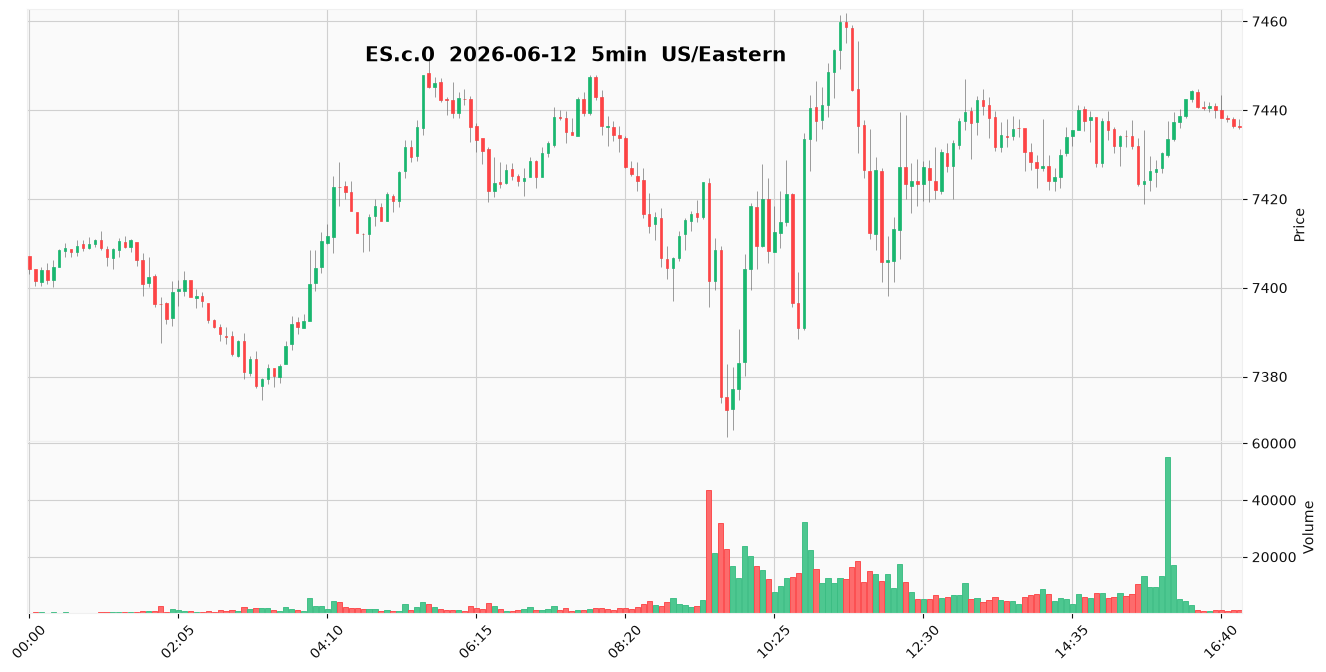

2026-06-12: 1,020 one-minute bars -> 204 5min candles


,open,high,low,close,volume
ts_event,,,,,
2026-06-12 00:00:00,7407.25,7407.25,7403.00,7404.25,208
2026-06-12 00:05:00,7404.25,7404.25,7400.50,7401.50,492
2026-06-12 00:10:00,7401.25,7404.75,7400.50,7404.00,468
2026-06-12 00:15:00,7404.00,7405.50,7400.75,7401.75,246
2026-06-12 00:20:00,7401.75,7406.25,7400.25,7404.75,447
...,...,...,...,...,...
2026-06-12 16:35:00,7441.00,7441.50,7438.25,7440.00,1112
2026-06-12 16:40:00,7440.00,7443.50,7438.25,7438.25,1303
2026-06-12 16:45:00,7438.25,7439.00,7437.25,7438.00,821


In [5]:
plot_daily_candles(full_df, "2026-06-12")

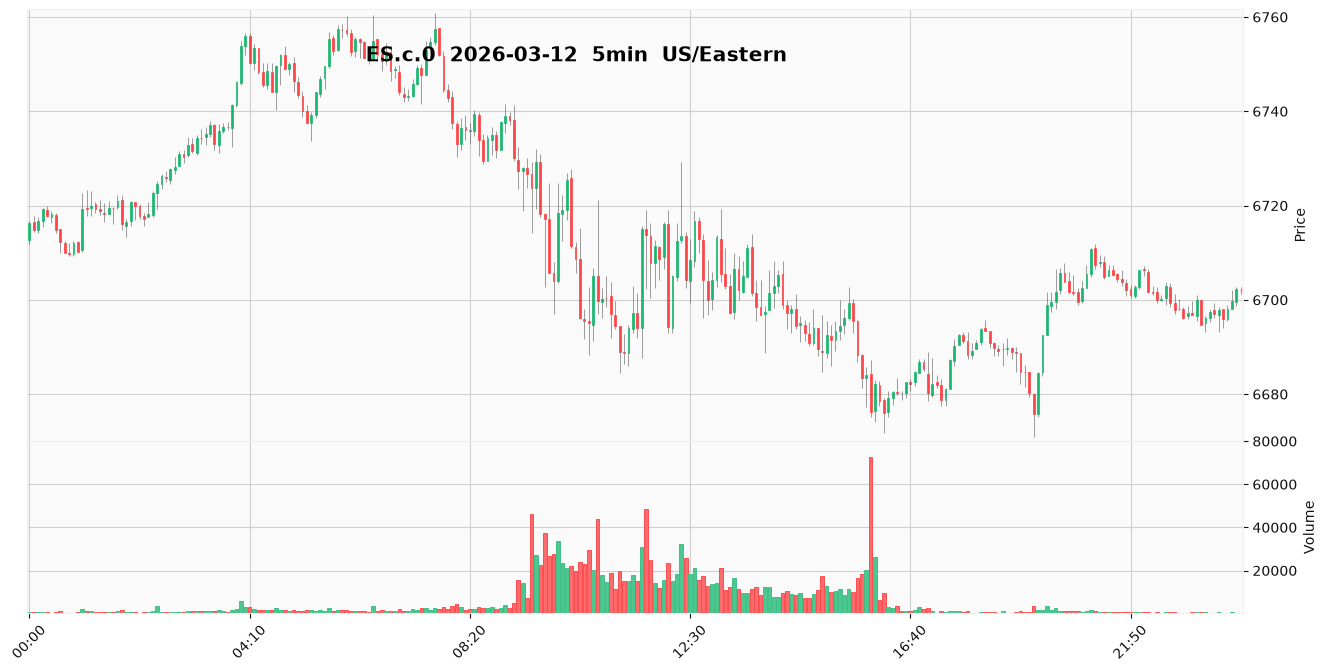

2026-03-12: 1,380 one-minute bars -> 276 5min candles


,open,high,low,close,volume
ts_event,,,,,
2026-03-12 00:00:00,6712.75,6716.75,6711.75,6716.25,829
2026-03-12 00:05:00,6716.50,6717.75,6714.50,6714.75,764
2026-03-12 00:10:00,6714.75,6717.50,6714.25,6716.75,551
2026-03-12 00:15:00,6716.75,6719.50,6715.50,6719.25,571
2026-03-12 00:20:00,6719.00,6720.00,6717.50,6717.75,561
...,...,...,...,...,...
2026-03-12 23:35:00,6698.00,6698.00,6694.00,6696.00,335
2026-03-12 23:40:00,6696.00,6699.00,6695.50,6698.00,447
2026-03-12 23:45:00,6698.00,6702.00,6698.00,6699.75,619


In [6]:
plot_daily_candles(full_df, "2026-03-12")